In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("Social_Network_Ads.csv")
dataset=df
dataset.describe()
dataset.isnull().sum()


User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Social_Network_Ads.csv")

#X=dataset.iloc[:,[2,3]].values
#y=dataset.iloc[:,4].values
X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
print(X_train.mean(axis=0))
print(X_train.std(axis=0))


[1.18423789e-17 5.92118946e-18]
[1. 1.]


In [12]:
from sklearn.tree import DecisionTreeClassifier
classifier=DecisionTreeClassifier(criterion='entropy',random_state=0)
classifier.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [13]:
y_pred=classifier.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0])

In [17]:
y_test


209    0
280    1
33     0
210    1
93     0
      ..
314    0
373    1
380    0
239    1
75     1
Name: Purchased, Length: 100, dtype: int64

In [22]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[55,  8],
       [ 9, 28]])

In [ ]:
accuacy=((cm[0][0]+cm[1][1])/(cm[0][0]+cm[1][0]+cm[0][1]+cm[1][1]))
accuacy

np.float64(0.83)

In [34]:
from sklearn import metrics
prediction=metrics.accuracy_score(y_test,y_pred)
print(prediction*100)

83.0


In [35]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87        63
           1       0.78      0.76      0.77        37

    accuracy                           0.83       100
   macro avg       0.82      0.81      0.82       100
weighted avg       0.83      0.83      0.83       100



In [58]:
new_individual=np.array([[20,20000]])
new_individual_scaled=sc.transform(new_individual)
prediction=classifier.predict(new_individual_scaled)
if prediction[0] == 1:
    print("the individual is predicted to purchase")
else:
    print(" the individual is predicted now to purchase")

 the individual is predicted now to purchase


c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Text(0.5405405405405406, 0.96875, 'x[0] <= 0.469\nentropy = 0.937\nsamples = 300\nvalue = [194.0, 106.0]'),
 Text(0.2972972972972973, 0.90625, 'x[1] <= 0.602\nentropy = 0.669\nsamples = 217\nvalue = [179, 38]'),
 Text(0.41891891891891897, 0.9375, 'True  '),
 Text(0.21621621621621623, 0.84375, 'x[0] <= -0.12\nentropy = 0.235\nsamples = 182\nvalue = [175, 7]'),
 Text(0.1891891891891892, 0.78125, 'entropy = 0.0\nsamples = 121\nvalue = [121, 0]'),
 Text(0.24324324324324326, 0.78125, 'x[1] <= -0.07\nentropy = 0.514\nsamples = 61\nvalue = [54, 7]'),
 Text(0.21621621621621623, 0.71875, 'entropy = 0.0\nsamples = 29\nvalue = [29, 0]'),
 Text(0.2702702702702703, 0.71875, 'x[1] <= 0.397\nentropy = 0.758\nsamples = 32\nvalue = [25, 7]'),
 Text(0.24324324324324326, 0.65625, 'x[0] <= 0.371\nentropy = 0.709\nsamples = 31\nvalue = [25, 6]'),
 Text(0.16216216216216217, 0.59375, 'x[1] <= 0.018\nentropy = 0.619\nsamples = 26\nvalue = [22, 4]'),
 Text(0.13513513513513514, 0.53125, 'entropy = 0.0\nsamples

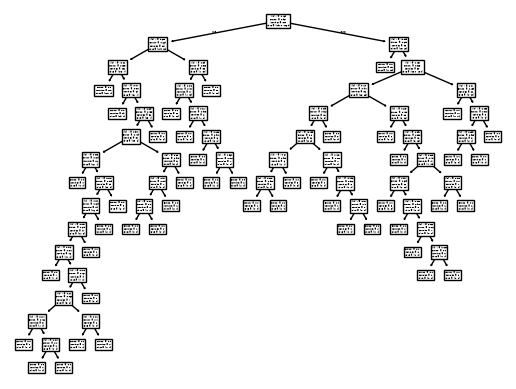

In [37]:
from sklearn import tree
tree.plot_tree(classifier)

Mean: [1.2490009e-16 0.0000000e+00]
Std: [1. 1.]
Confusion Matrix:
[[133  16]
 [ 19  72]]
Accuracy: 85.41666666666666 %
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       149
           1       0.82      0.79      0.80        91

    accuracy                           0.85       240
   macro avg       0.85      0.84      0.84       240
weighted avg       0.85      0.85      0.85       240

The individual is predicted not to purchase


c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Text(0.4396551724137931, 0.9545454545454546, 'x[0] <= 0.398\ngini = 0.439\nsamples = 160\nvalue = [108, 52]'),
 Text(0.22413793103448276, 0.8636363636363636, 'x[1] <= 0.706\ngini = 0.249\nsamples = 110\nvalue = [94, 16]'),
 Text(0.3318965517241379, 0.9090909090909092, 'True  '),
 Text(0.10344827586206896, 0.7727272727272727, 'x[0] <= -0.077\ngini = 0.061\nsamples = 95\nvalue = [92, 3]'),
 Text(0.06896551724137931, 0.6818181818181818, 'gini = 0.0\nsamples = 69\nvalue = [69, 0]'),
 Text(0.13793103448275862, 0.6818181818181818, 'x[1] <= 0.211\ngini = 0.204\nsamples = 26\nvalue = [23, 3]'),
 Text(0.06896551724137931, 0.5909090909090909, 'x[1] <= -0.022\ngini = 0.095\nsamples = 20\nvalue = [19, 1]'),
 Text(0.034482758620689655, 0.5, 'gini = 0.0\nsamples = 13\nvalue = [13, 0]'),
 Text(0.10344827586206896, 0.5, 'x[1] <= 0.118\ngini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.06896551724137931, 0.4090909090909091, 'x[0] <= 0.161\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.03448275

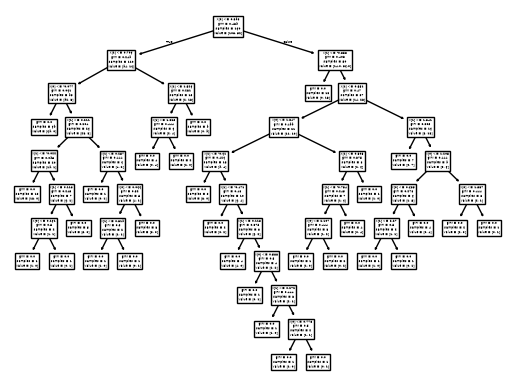

In [72]:
#using gini 
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Load dataset
df = pd.read_csv("Social_Network_Ads.csv")

# Features and target
X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.6,
    random_state=42
)

# Standardization
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Check standardization
print("Mean:", X_train.mean(axis=0))
print("Std:", X_train.std(axis=0))

# Create Decision Tree
classifier = DecisionTreeClassifier(
    criterion="gini",
    random_state=0
)

# Train model
classifier.fit(X_train, y_train)

# Predict test data
y_pred = classifier.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100, "%")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Predict a new individual
new_individual = np.array([[20, 20000]])

# IMPORTANT: use the same scaler
new_individual_scaled = sc.transform(new_individual)

# Make prediction
prediction = classifier.predict(new_individual_scaled)

if prediction[0] == 1:
    print("The individual is predicted to purchase")
else:
    print("The individual is predicted not to purchase")
from sklearn import tree
tree.plot_tree(classifier)

based on the experimentation done for the test size
the observations found are:
for 0.1 : 82.3%
for 0.2 : 83.25%
for 0.25 : 83%
for 0.3 : 84.16%
for 0.35 : 87.14%
for 0.4: 87.5%
for 0.45: 88.3%
for 0.5: 88.5%
for 0.55: 86.4%
for 0.6: 85.4%